# How big is that correlation?

Elements of Data Science

by [Allen Downey](https://allendowney.com)

[MIT License](https://opensource.org/licenses/MIT)

In [1]:
# If we're running on Colab, install empiricaldist
# https://pypi.org/project/empiricaldist/

import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !pip install empiricaldist

In [2]:
import numpy as np
import pandas as pd

np.random.seed(17)

## Standardized slope

In [3]:
rho = 0.36

In [4]:
from scipy.stats import norm

dist = norm(0, 1)
dist.cdf(1), dist.cdf(rho)

(np.float64(0.8413447460685429), np.float64(0.6405764332179913))

Someone with g = 1 SDM is expected to have gfp = 0.36 SDM on average.

So if they're in the 84th percentile of intelligence, we expect them to be in the 64th percentile of personality.

The function below generates correlated numbers. It is based on the following mathematical relationship between the Pearson's correlation coefficient, the sum of the square of the residuals and standard deviations. It will work under regression through the L2 norm, which is the most common one used in Ordinary Least Squares because the residuals mean will be approximately zero $(\bar{r} \approx 0)$
$$\rho = \frac{\sigma_{xy}}{\sigma_x \sigma_y}$$

$$ \sigma_x^2 = \frac{1}{N}\sum (x_i - \bar{x})^2 $$

$$ \sigma_r^2 = \frac{1}{N}\sum (r_i - \bar{r})^2 \quad ; \bar{r} \approx 0 
\therefore \sigma_r^2 \approx \frac{1}{N}\sum r_i^2 =
\frac{1}{N}\sum (x_i - \hat{x_i})^2
$$

$$ \frac{SS_{res_{\hat{x}}}}{N} = \frac{1}{N}\sum r_{\hat{x}_i}^2 = \frac{1}{N}\sum (x_i - \hat{x_i})^2
= \sigma_{\hat{x}}^2 \approx \sigma_r^2$$

$$ \frac{SS_{res_x}}{N} = \frac{1}{N}\sum r_x^2 = \frac{1}{N}\sum (x_i - \bar{x})^2 = \sigma_x^2$$

$$R^2 = 1 - \frac{SS_{res_{\hat{x}}}}{SS_{res_{\overline{x}}}} = \text{FVE} = 1 - \frac{\sigma_{\hat{x}}^2}{\sigma_x^2} = \rho^2
\therefore \sigma_{\hat{x}}^2 = (1 - \rho^2)\sigma_x^2
$$

In [5]:
def generate_correlated(xs, rho):
    mus = rho * xs
    sigma = np.sqrt(1 - rho**2)
    return np.random.normal(mus, sigma)


def generate_correlated_v2(xs, rho):
    xhat_std = np.sqrt((1-rho**2)*xs.var())
    ys_mus = xs*rho
    ys = ys_mus + norm.rvs(0, xhat_std, size=len(xs))
    return ys

In [6]:
xs = np.random.normal(0, 1, size=10000)
ys = generate_correlated(xs, rho=0.36)
ys_v2 = generate_correlated_v2(xs, rho=0.36)
np.corrcoef(xs, ys)[0,1], np.corrcoef(xs, ys_v2)[0,1]

(np.float64(0.3590685918865528), np.float64(0.35824692533928115))

In [7]:
test_x = generate_correlated(xs, 0.8)
test_y = generate_correlated(ys, 0.8)
np.corrcoef(test_x, test_y)

array([[1.        , 0.23006783],
       [0.23006783, 1.        ]])

## gfp and g

For this example, you don't have to believe that gfp or g are real.

Some measurable cognitive capability,

and some way to quantify characteristics of personality on a scale from less to more desirable, according to the preferences of others.

In [8]:
g = xs
gfp = ys

And here's what the distribution looks like.

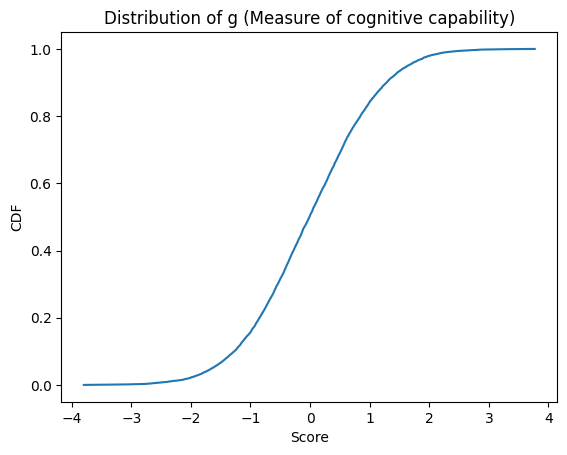

In [9]:
from empiricaldist import Cdf
import matplotlib.pyplot as plt

Cdf.from_seq(g).plot()
plt.xlabel('Score')
plt.ylabel('CDF')
plt.title('Distribution of g (Measure of cognitive capability)')
plt.show()

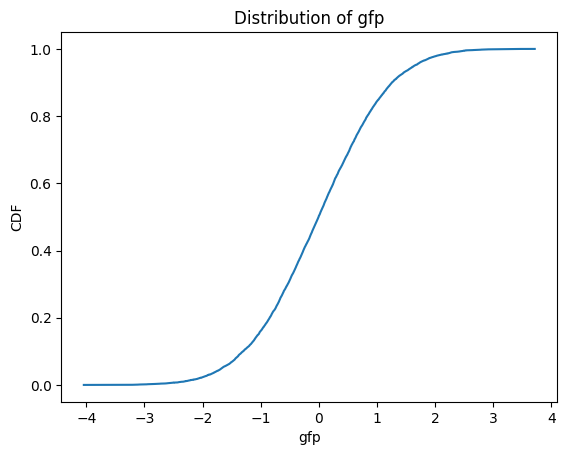

In [10]:
Cdf.from_seq(gfp).plot()
plt.xlabel('gfp')
plt.ylabel('CDF')
plt.title('Distribution of gfp')
plt.show()

The mean and standard deviation are near 0 and 1, as desired.

In [11]:
g.mean(), g.std()

(np.float64(-0.006796445530111587), np.float64(1.0008011536496255))

In [12]:
gfp.mean(), gfp.std()

(np.float64(-0.007494755145973499), np.float64(1.0010584830037055))

And the correlation is near $\rho$.

In [13]:
a = np.corrcoef(g, gfp)
rho_actual = a[0, 1]
rho_actual

np.float64(0.3590685918865528)

This scatterplot shows the relationship between gfp and SAT in my simulated dataset.

In [14]:
from matplotlib.colors import ListedColormap

def scatter(df, selector, color='C0', title=''):
    cmap = ListedColormap(['C1', color])
    subset = df.loc[:1000]
    plt.scatter(subset['g'], subset['gfp'], c=subset[selector], cmap=cmap, s=15, alpha=0.3)
    plt.xlabel('g')
    plt.ylabel('gfp')
    plt.title(title)

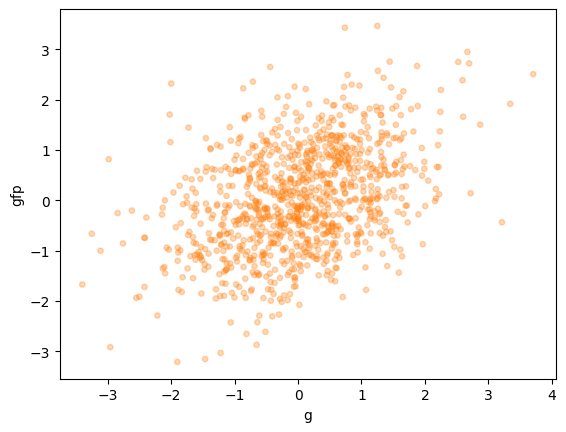

In [15]:
df = pd.DataFrame(dict(g=g, gfp=gfp, all=1))

scatter(df, 'all')

## Predictive value

Reduction in variance

In [16]:
rho ** 2

0.1296

In [17]:
import statsmodels.formula.api as smf

results = smf.ols('gfp ~ g', data=df).fit()

In [18]:
MAE_after = np.abs(results.resid).mean()
MAE_after

np.float64(0.7485517889663356)

In [19]:
deviation = gfp - gfp.mean()
MAE_before = np.abs(deviation).mean()
MAE_before

np.float64(0.8001193291587837)

In [20]:
improvement = 1 - MAE_after / MAE_before
improvement

np.float64(0.06444981181327591)

So we can say that knowing $g$ decreases the MAE by 7%.

That is certainly an improvement, but notice that it sounds less impressive than $R^2 = 0.13$ and much less impressive than $r = 0.36$.

## Classification accuracy

In [21]:
df['smart'] = df['g'] > 0
df['nice'] = df['gfp'] > 0
p = df.query('smart')['nice'].mean()
RR = p / 0.5
K = p / (1-p)
p, RR, K

(np.float64(0.615819209039548),
 np.float64(1.231638418079096),
 np.float64(1.602941176470588))

In [22]:
df['smart'] = df['g'] > 1
df['nice'] = df['gfp'] > 0
p = df.query('smart')['nice'].mean()
RR = p / 0.5
K = p / (1-p)
p, RR, K

(np.float64(0.7040557667934094),
 np.float64(1.4081115335868188),
 np.float64(2.3790149892933625))

According to https://www.statlect.com/fundamentals-of-statistics/Jeffreys-scale

This value of K is "barely worth mentioning" or "anecdotal"

## Prevalence of having it all

In [23]:
import pandas as pd

thresh = 1
both = (g > thresh) & (gfp > thresh)
combo = (g + gfp) > 2
anti = ((g > 1) & (gfp < -1)) | ((g < -1) & (gfp > 1))
df = pd.DataFrame(dict(g=g, gfp=gfp, both=both, combo=combo, anti=anti))
both.mean(), combo.mean()

(np.float64(0.0486), np.float64(0.1088))

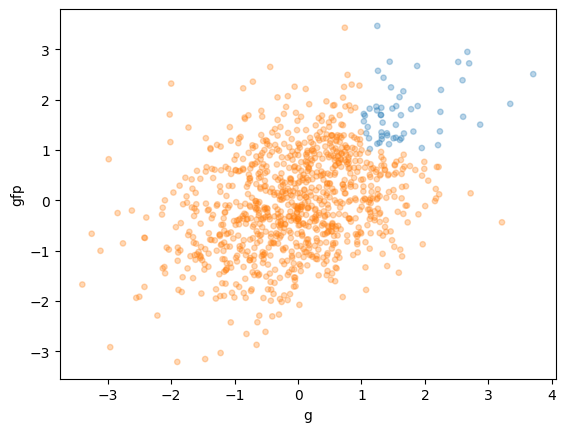

In [24]:
scatter(df, 'both', 'C0')

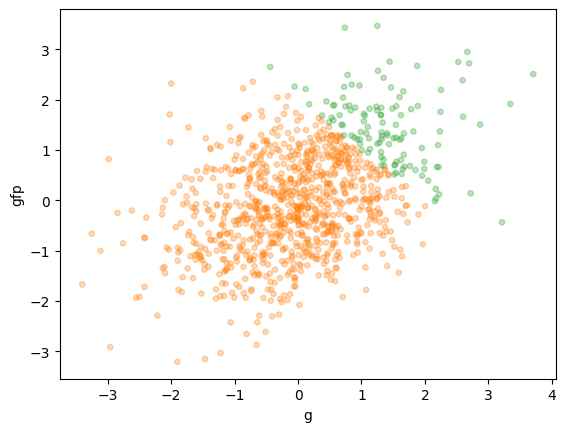

In [25]:
scatter(df, 'combo', 'C2')

If there were no correlation, how many people would be 1 standard deviation above the mean on both?

In [26]:
from scipy.stats import norm

one = norm(0, 1).sf(thresh)
both = one**2
one, both

(np.float64(0.15865525393145707), np.float64(0.025171489600055125))

* The variancies of g and gfp are both 1, so the variance of the sum is 2.
* sf means "survival function", which is 1 - cdf.
* 2 is used in sf because we are looking at the probability the sum of g and gfp is greater than 2.

In [27]:
combo = norm(0, np.sqrt(2)).sf(2)
combo

np.float64(0.07864960352514258)

In [28]:
# double-checking the analytic result with simulation
x = np.random.normal(0, 1, size=10000)
y = np.random.normal(0, 1, size=10000)
both = (x>1) & (y>1)
combo = (x + y) > 2
both.mean(), combo.mean()

(np.float64(0.0259), np.float64(0.0813))

In [29]:
df['both'].mean(), df['combo'].mean()

(np.float64(0.0486), np.float64(0.1088))

## Pearson's correlation coefficient and selection bias

A weak correlation can be wiped out by a weak selection process, and reversed by a strong one.

### What does it mean for a correlation to be wiped out by a weak selection process and reversed by a strong one?

When we select a subset of data based on a combination of variables, the observed correlation between those variables in the selected group can change dramatically compared to the original population. This is known as **selection bias**.

### Wiped Out by a Weak Selection Process

A **weak selection process** means we select a large fraction of the population (e.g., the top 70% based on the sum of two scores). In this case, the correlation between the two variables in the selected group can be much lower than in the full population, sometimes close to zero.

**Example:**  
Suppose $g$ and $gfp$ have a correlation of $0.36$ in the full dataset. If we select everyone whose $g + gfp$ is above a low threshold (admitting about 66% of people), the correlation among the selected group can drop to zero. This means that, within the selected group, knowing $g$ tells you almost nothing about $gfp$.

### Reversed by a Strong Selection Process

A **strong selection process** means we select only a small fraction of the population (e.g., the top 10% based on the sum of two scores). In this case, the correlation between the two variables in the selected group can become **negative**, even if it was positive in the full population.

**Example:**  
Again, suppose $g$ and $gfp$ have a correlation of $0.36$ in the full dataset. If we select only those whose $g + gfp$ is above a high threshold (admitting only 10% of people), the correlation among the selected group can become negative (e.g., $-0.48$). This means that, within the selected group, higher $g$ is associated with lower $gfp$, and vice versa.

### Why does this happen?

When selection is based on the sum (or another combination) of two variables, it creates a dependency: if one variable is high, the other doesn't need to be as high to meet the threshold. This can reduce or even reverse the observed correlation in the selected group.

### Summary Table

| Selection Fraction | Observed Correlation in Selected Group |
|--------------------|---------------------------------------|
| 66%                | 0 (wiped out)                         |
| 40%                | -0.2 (reversed, negative)             |
| 10%                | -0.48 (strongly reversed)             |

**In short:**  
Selection on a combination of variables can dramatically change the observed correlation, sometimes making it disappear (wiped out) or even flip sign (reversed).

In [30]:
# generate a bigger dataset so we can simulate strong selection

g = np.random.normal(0, 1, size=100000)
gfp = generate_correlated(g, rho)
df_big = pd.DataFrame(dict(g=g, gfp=gfp))

In [31]:
res = []

for thresh in np.linspace(-4, 3):
    selected = (g + gfp) > thresh
    frac = selected.mean()
    corr = df_big.loc[selected, ['g', 'gfp']].corr()
    res.append((thresh, frac, corr.iloc[0, 1]))

ts, fs, cs = np.transpose(res)

In [32]:
from scipy.interpolate import interp1d

f_example = np.array([0.7, 0.4, 0.1])
c_example = interp1d(fs, cs)(f_example)
c_example

array([ 0.0301871 , -0.19463012, -0.47819825])

Text(0, 0.5, 'Correlation')

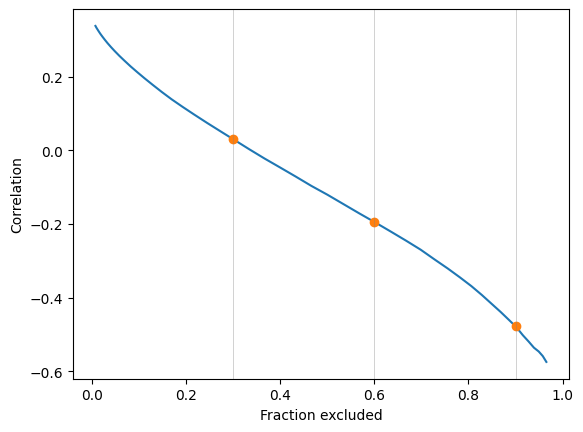

In [33]:
plt.plot(1-fs, cs)
plt.plot(1-f_example, c_example, 'o')

for f in f_example:
    plt.axvline(1-f, color='gray', lw=0.5, alpha=0.5)
plt.xlabel('Fraction excluded')
plt.ylabel('Correlation')

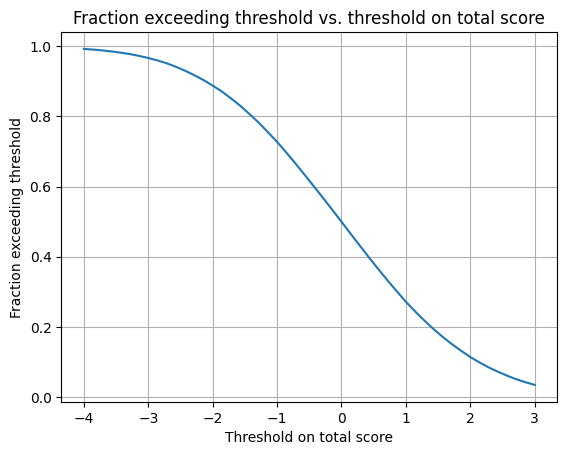

In [34]:
plt.plot(ts, fs)
plt.xlabel('Threshold on total score')
plt.ylabel('Fraction exceeding threshold')
plt.grid()
plt.title('Fraction exceeding threshold vs. threshold on total score')
plt.show()

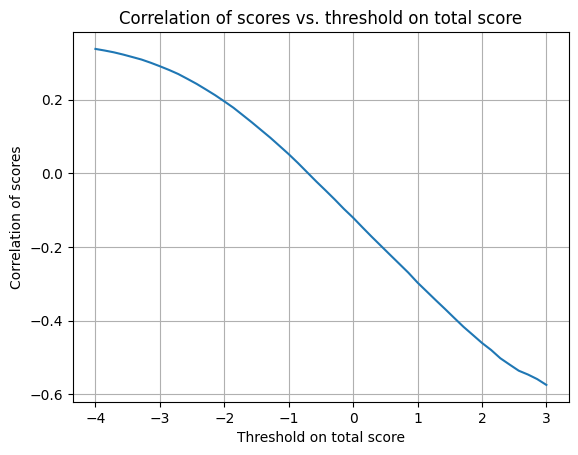

In [35]:
plt.plot(ts, cs)
plt.xlabel('Threshold on total score')
plt.ylabel('Correlation of scores')
plt.grid()
plt.title('Correlation of scores vs. threshold on total score')
plt.show()

The correlation is 0 when the we admit about 66%

In [36]:
from scipy.interpolate import interp1d

interp1d(cs, fs)(0)

array(0.66211187)

At 40% selected, correlation is -0.2

In [37]:
interp1d(fs, cs)(0.4)

array(-0.19463012)

At 10% selected, correlation is -0.48

In [38]:
interp1d(fs, cs)(0.1)

array(-0.47819825)

## Missing variable bias

**Missing variable bias** (also called omitted variable bias) occurs when a relevant variable is left out of a regression model. This can lead to biased and misleading estimates of the effect of the included variables.

In the context of this notebook, suppose we want to predict an outcome that depends on two variables, $x$ and $y$, but we only include $x$ in our regression model and omit $y$. If $x$ and $y$ are correlated, the estimated effect of $x$ on the outcome will be biased because it will (incorrectly) absorb some of the effect of $y$.

### Example

Suppose the true relationship is:
$$
\text{outcome} = x + y + \text{noise}
$$

If we fit a regression model using both $x$ and $y$, we recover the correct coefficients (close to 1 for both $x$ and $y$).


In [39]:
outcome = xs + ys + np.random.normal(0, 2, size=len(xs))

In [40]:
df = pd.DataFrame(dict(xs=xs, ys=ys, outcome=outcome))

In [41]:
import statsmodels.formula.api as smf

results = smf.ols('outcome ~ xs + ys', data=df).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                outcome   R-squared:                       0.410
Model:                            OLS   Adj. R-squared:                  0.410
Method:                 Least Squares   F-statistic:                     3476.
Date:                Sat, 07 Jun 2025   Prob (F-statistic):               0.00
Time:                        09:10:34   Log-Likelihood:                -21058.
No. Observations:               10000   AIC:                         4.212e+04
Df Residuals:                    9997   BIC:                         4.214e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0262      0.020      1.319      0.187      -0.013       0.065
xs             1.0050      0.021     47.226      0.000       0.963       1.047
ys             1.0037      0.021     47.177      0.000       0.962       1.045
==============================================================================
Omnibus:                        9.367   Durbin-Watson:                   1.993
Prob(Omnibus):                  0.009   Jarque-Bera (JB):               10.494
Skew:                           0.018   Prob(JB):                      0.00526
Kurtosis:                       3.155   Cond. No.                         1.46
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Now, suppose we omit $y$ and fit a regression with only $x$:

In [42]:
results = smf.ols('outcome ~ xs', data=df).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                outcome   R-squared:                       0.279
Model:                            OLS   Adj. R-squared:                  0.279
Method:                 Least Squares   F-statistic:                     3866.
Date:                Sat, 07 Jun 2025   Prob (F-statistic):               0.00
Time:                        09:10:34   Log-Likelihood:                -22063.
No. Observations:               10000   AIC:                         4.413e+04
Df Residuals:                    9998   BIC:                         4.414e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0211      0.022      0.962      0.336      -0.022       0.064
xs             1.3655      0.022     62.180      0.000       1.322       1.409
==============================================================================
Omnibus:                        8.594   Durbin-Watson:                   1.989
Prob(Omnibus):                  0.014   Jarque-Bera (JB):                9.490
Skew:                          -0.022   Prob(JB):                      0.00870
Kurtosis:                       3.144   Cond. No.                         1.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Notice that the coefficient for $x$ is now much larger than 1. This is because the effect of $y$ (which is correlated with $x$) is incorrectly attributed to $x$. This is **missing variable bias**: omitting a relevant variable leads to biased estimates for the variables that are included.


The coefficient for `xs` becomes much larger than 1. This happens because `ys` is correlated with xs, and the model tries to "explain" the effect of both variables using only `xs`. As a result, the effect of `ys` is incorrectly attributed to `xs`, leading to a biased estimate.

### Why is it relevant to consider missing or omitted variable bias?

Omitted variable bias is crucial to consider in statistical modeling and data analysis because leaving out a relevant variable can lead to misleading or incorrect conclusions about the relationships between variables. When a variable that influences the outcome is omitted from a regression model, the estimated effects of the included variables can be biased—meaning they do not reflect the true relationship in the data.

This bias occurs especially when the omitted variable is correlated with both the included predictor(s) and the outcome. In such cases, the model incorrectly attributes some of the effect of the omitted variable to the included variables, distorting the interpretation of the results.

Why does this matter?
* **Misleading conclusions**: If you interpret the coefficient of xs as its true effect on the outcome, you will overestimate its importance.
* **Policy and decision errors**: In real-world applications, such as economics, medicine, or social sciences, omitted variable bias can lead to poor decisions or ineffective interventions.
* **Scientific rigor**: Recognizing and addressing omitted variable bias is essential for building valid, reliable models and for drawing accurate inferences from data.

**In summary**, omitted variable bias can significantly distort the results of your analysis. Always consider whether important variables might be missing from your model, especially if they are likely to be correlated with both the predictors and the outcome.

